In [ ]:
import marimo as mo

# SimulateFactory configurable example

This notebook shows how far the simulator can be customized without
changing the generation code: custom product masses, custom smear functions,
seed control, and detector-like pt perturbations from different
distributions.

## Import and configure

We define two custom smear functions that modify only transverse momentum.
One uses a Gaussian perturbation, the other uses a Laplace-shaped draw.

In [ ]:
import matplotlib.pyplot as plt
import torch

from ttpd.generator import SimulateFactory as _SimulateFactory
from ttpd.kinematics import invariant_mass_from_ptphieta, mMu, mZ0

def gaussian_pt_smear(
    batch_decay_vectors: torch.Tensor, seed: int | None = None
) -> torch.Tensor:
    generator = torch.Generator(device=batch_decay_vectors.device)
    if seed is not None:
        generator.manual_seed(seed)

    value = batch_decay_vectors.clone()
    scale = torch.normal(
        mean=torch.ones(value.shape[0], device=value.device),
        std=torch.full((value.shape[0],), 0.04, device=value.device),
        generator=generator,
    )
    value[:, 0] *= scale
    value[:, 4] *= scale
    return value

def laplace_pt_smear(
    batch_decay_vectors: torch.Tensor, seed: int | None = None
) -> torch.Tensor:
    generator = torch.Generator(device=batch_decay_vectors.device)
    if seed is not None:
        generator.manual_seed(seed)

    value = batch_decay_vectors.clone()
    uniform = torch.rand(value.shape[0], generator=generator, device=value.device)
    uniform = uniform - 0.5
    scale = 1.0 - 0.03 * torch.sign(uniform) * torch.log1p(
        -2.0 * torch.abs(uniform)
    )
    value[:, 0] *= scale
    value[:, 4] *= scale
    return value

gaussian_factory = _SimulateFactory.create(
    product_mass=mMu,
    smearer=gaussian_pt_smear,
    device=torch.device("cpu"),
)
laplace_factory = _SimulateFactory.create(
    product_mass=mMu,
    smearer=laplace_pt_smear,
    device=torch.device("cpu"),
)

## Generate comparable samples

We keep the generation seed fixed and vary only the smearing model. That
makes it easy to isolate the detector-response effect.

In [ ]:
theta = torch.hstack(
    [
        torch.full((2_000, 1), mZ0),
        torch.zeros((2_000, 1)),
    ]
)

gaussian_events = gaussian_factory.simulate(theta, generation_seed=7, smear_seed=11)
laplace_events = laplace_factory.simulate(theta, generation_seed=7, smear_seed=11)

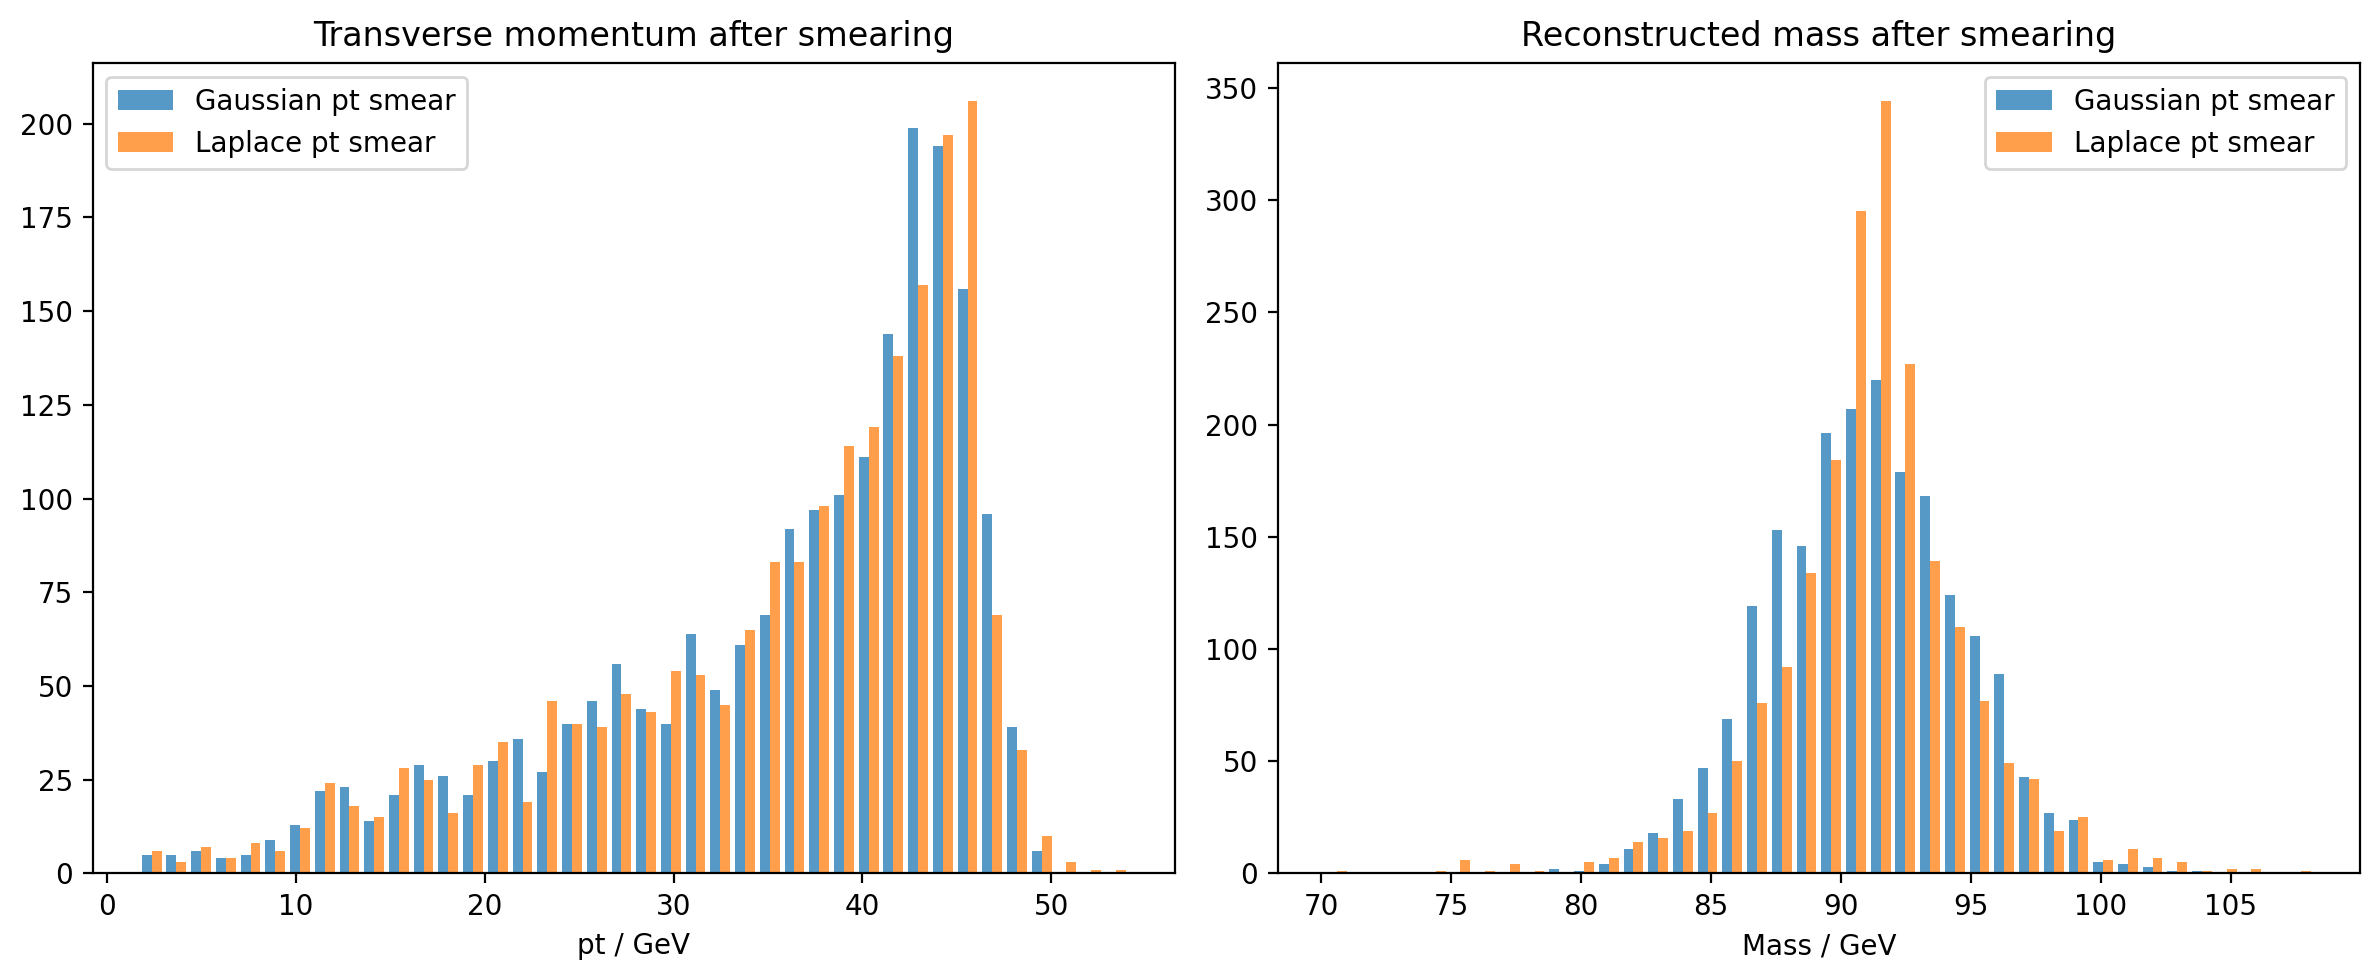

In [ ]:
gaussian_pt = gaussian_events[:, 0].flatten()
laplace_pt = laplace_events[:, 0].flatten()
gaussian_mass = invariant_mass_from_ptphieta(gaussian_events).flatten()
laplace_mass = invariant_mass_from_ptphieta(laplace_events).flatten()

_fig, _axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

_axes[0].hist(
    [gaussian_pt.numpy(), laplace_pt.numpy()],
    bins=40,
    alpha=0.75,
    label=["Gaussian pt smear", "Laplace pt smear"],
)
_axes[0].set_title("Transverse momentum after smearing")
_axes[0].set_xlabel("pt / GeV")
_axes[0].legend()

_axes[1].hist(
    [gaussian_mass.numpy(), laplace_mass.numpy()],
    bins=40,
    alpha=0.75,
    label=["Gaussian pt smear", "Laplace pt smear"],
)
_axes[1].set_title("Reconstructed mass after smearing")
_axes[1].set_xlabel("Mass / GeV")
_axes[1].legend()

_fig